# **Student Database Analytics System using SQLite**

In [1]:
from google.colab import files

uploaded = files.upload()

Saving student_performance.csv to student_performance.csv


**Import Libraries**

In [2]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Load Dataset**

In [3]:
df = pd.read_csv("student_performance.csv")

df.head()

,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023
3,1004,Sneha Reddy,20,Female,Mechanical,2,70,80,75,48,95,Hyderabad,2023
4,1005,Arjun Nair,19,Male,Computer Science,2,92,88,81,95,90,Kochi,2023


**Create SQLite Database**

In [4]:
conn = sqlite3.connect(":memory:")

cursor = conn.cursor()

**Create Normalized Tables**

**Departments**

In [5]:
cursor.execute("""
CREATE TABLE Departments(
    department_id INTEGER PRIMARY KEY,
    department_name TEXT
)
""")

**Students**

In [6]:
cursor.execute("""
CREATE TABLE Students(
    student_id INTEGER PRIMARY KEY,
    name TEXT,
    gender TEXT,
    attendance_percentage REAL,
    department_id INTEGER,

    FOREIGN KEY(department_id)
    REFERENCES Departments(department_id)
)
""")

**Scores**

In [7]:
cursor.execute("""
CREATE TABLE Scores(
    student_id INTEGER,
    math_score REAL,
    science_score REAL,
    english_score REAL,
    programming_score REAL,

    FOREIGN KEY(student_id)
    REFERENCES Students(student_id)
)
""")

**Populate Department Table**

In [8]:
departments = df['department'].unique()

dept_map = {}

for i, dept in enumerate(departments, start=1):
    dept_map[dept] = i

    cursor.execute("""
    INSERT INTO Departments
    VALUES (?,?)
    """,(i,dept))

**Insert Student Records**

In [9]:
for _, row in df.iterrows():

    cursor.execute("""
    INSERT INTO Students
    VALUES (?,?,?,?,?)
    """,(
        row['student_id'],
        row['name'],
        row['gender'],
        row['attendance_percentage'],
        dept_map[row['department']]
    ))

**Insert Scores**

In [10]:
for _, row in df.iterrows():

    cursor.execute("""
    INSERT INTO Scores
    VALUES (?,?,?,?,?)
    """,(
        row['student_id'],
        row['math_score'],
        row['science_score'],
        row['english_score'],
        row['programming_score']
    ))

In [11]:
conn.commit()

**Query 1**

**Student Count per Department**

In [12]:
query = """
SELECT d.department_name,
       COUNT(*) AS student_count
FROM Students s
JOIN Departments d
ON s.department_id=d.department_id
GROUP BY d.department_name
"""

pd.read_sql(query, conn)

,department_name,student_count
0,Civil,5
1,Computer Science,13
2,Electronics,6
3,Mechanical,6


**Query 2**

**Average Attendance per Department**

In [15]:
query = """
SELECT d.department_name,
       AVG(s.attendance_percentage)
FROM Students s
JOIN Departments d
ON s.department_id=d.department_id
GROUP BY d.department_name
"""
result = pd.read_sql(query, conn)

print(result)

    department_name  AVG(s.attendance_percentage)
0             Civil                     74.600000
1  Computer Science                     90.692308
2       Electronics                     80.333333
3        Mechanical                     83.500000


**Query 3 (HAVING)**

**Departments with more than 5 students**

In [17]:
query = """
SELECT d.department_name,
       COUNT(*) total_students

FROM Students s
JOIN Departments d
ON s.department_id=d.department_id

GROUP BY d.department_name

HAVING COUNT(*) > 5
"""

result = pd.read_sql(query, conn)
print(result)

    department_name  total_students
0  Computer Science              13
1       Electronics               6
2        Mechanical               6


**Query 4 (Subquery)**

**Highest Average Scoring Student**

In [19]:
query = """
SELECT *
FROM Students

WHERE student_id =

(
SELECT student_id

FROM Scores

ORDER BY
(
math_score +
science_score +
english_score +
programming_score
) DESC

LIMIT 1
)
"""
result = pd.read_sql(query, conn)
print(result)

   student_id        name  gender  attendance_percentage  department_id
0        1010  Ananya Das  Female                   98.0              1


**Query 5 (AVG)**

**Overall Average Score**

In [21]:
query = """
SELECT AVG(
(
math_score +
science_score +
english_score +
programming_score
)/4
) AS AverageScore

FROM Scores
"""
result = pd.read_sql(query, conn)
print(result)


   AverageScore
0     73.916667


**Query 6 (MAX)**

**Highest Programming Score**

In [22]:
query = """
SELECT MAX(programming_score)
FROM Scores
"""
result = pd.read_sql(query, conn)
print(result)

   MAX(programming_score)
0                    97.0


**Query 7 (MIN)**

**Lowest Attendance**

In [23]:
query = """
SELECT MIN(attendance_percentage)
FROM Students
"""
result = pd.read_sql(query, conn)
print(result)


   MIN(attendance_percentage)
0                        65.0


**Query 8 (SUM)**

**Total Attendance Points**

In [24]:
query = """
SELECT SUM(attendance_percentage)
FROM Students
"""
result = pd.read_sql(query, conn)
print(result)


   SUM(attendance_percentage)
0                      2535.0


**Visualizations**



**Department-wise Student Count**

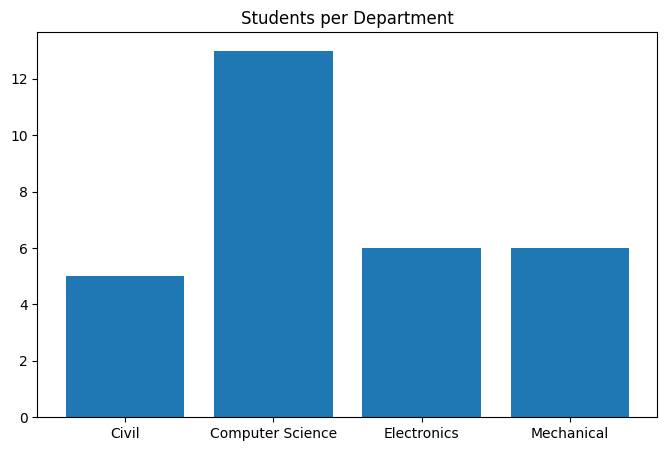

In [25]:
query = """
SELECT d.department_name,
COUNT(*) count

FROM Students s
JOIN Departments d

ON s.department_id=d.department_id

GROUP BY d.department_name
"""

result = pd.read_sql(query, conn)

plt.figure(figsize=(8,5))

plt.bar(
    result['department_name'],
    result['count']
)

plt.title("Students per Department")

plt.savefig(
    "department_student_count.png"
)

plt.show()

**Average Score by Department**

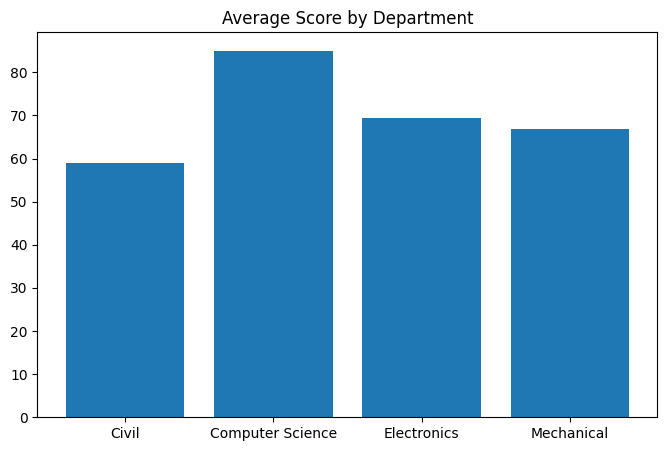

In [26]:
query = """
SELECT d.department_name,

AVG(
(
sc.math_score +
sc.science_score +
sc.english_score +
sc.programming_score
)/4
) avg_score

FROM Students s

JOIN Scores sc
ON s.student_id=sc.student_id

JOIN Departments d
ON s.department_id=d.department_id

GROUP BY d.department_name
"""

result = pd.read_sql(query, conn)

plt.figure(figsize=(8,5))

plt.bar(
    result['department_name'],
    result['avg_score']
)

plt.title("Average Score by Department")

plt.savefig(
    "department_avg_score.png"
)

plt.show()

**Gender Distribution**

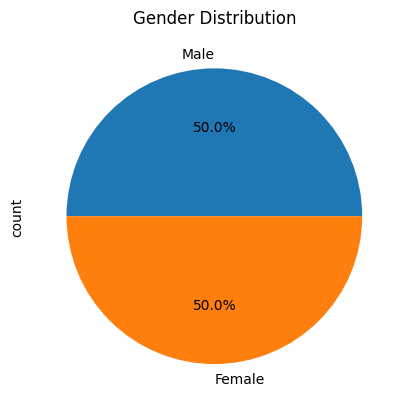

In [27]:
df['gender'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Gender Distribution")

plt.savefig(
    "gender_distribution.png"
)

plt.show()

**Attendance Distribution**

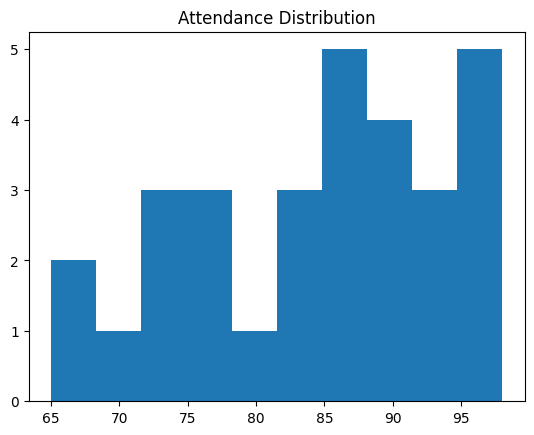

In [28]:
plt.hist(
    df['attendance_percentage'],
    bins=10
)

plt.title(
    "Attendance Distribution"
)

plt.savefig(
    "attendance_distribution.png"
)

plt.show()

**Top 10 students**

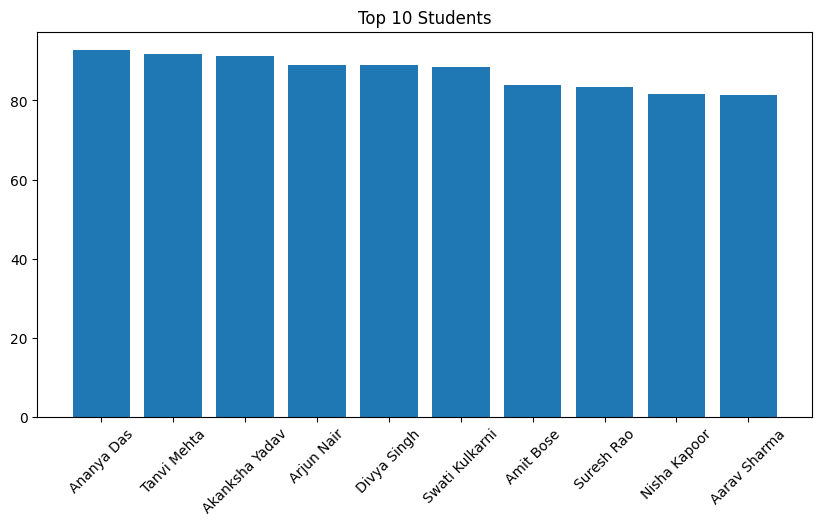

In [29]:
df['avg_score'] = (
    df['math_score']
    + df['science_score']
    + df['english_score']
    + df['programming_score']
)/4

top10 = df.sort_values(
    by='avg_score',
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

plt.bar(
    top10['name'],
    top10['avg_score']
)

plt.xticks(rotation=45)

plt.title(
    "Top 10 Students"
)

plt.savefig(
    "top_students.png"
)

plt.show()